# Install transformers

In [1]:
! pip install transformers datasets torch

# Imports

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import torch
from torch.utils.data import Dataset as TorchDataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"GPU" if torch.cuda.is_available() else "CPU"}') 

PyTorch version: 2.12.0+cpu
Device: CPU


## 3. Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────
DATA_DIR   = r"E:\Project Demo\data"
OUTPUT_DIR = r"E:\Project Demo\models\nlp_model"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Model ──────────────────────────────────────────────
MODEL_NAME  = "xlm-roberta-base"   # multilingual: English + Bangla
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 3
LEARNING_RATE = 2e-5
SEED        = 42

# ── Labels ─────────────────────────────────────────────
# 0 = Legitimate  |  1 = Phishing
LABEL2ID = {'legitimate': 0, 'phishing': 1}
ID2LABEL = {0: 'legitimate', 1: 'phishing'}

print('Config loaded.')

Config loaded.


## 4. Load & Merge Datasets

In [ ]:
# ── Loader + Load All Datasets (ONE CELL) ─────────────
frames = []

def load_csv(filename, text_col, label_col, phishing_values,
             encoding='utf-8', xlsx=False):
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f'  [SKIP] Not found: {filename}')
        return None
    try:
        if xlsx:
            df = pd.read_excel(path)
        else:
            df = pd.read_csv(path, encoding=encoding, on_bad_lines='skip')
        if text_col not in df.columns or label_col not in df.columns:
            print(f'  [SKIP] {filename} — column missing')
            return None
        df = df[[text_col, label_col]].copy()
        df.columns = ['text', 'raw_label']
        df['label'] = df['raw_label'].astype(str).str.strip().str.lower().apply(
            lambda x: 1 if x in [str(v).lower() for v in phishing_values] else 0)
        df = df[['text','label']].dropna()
        df['text'] = df['text'].astype(str).str.strip()
        df = df[df['text'].str.len() > 5]
        print(f'  [OK]  {filename} → {len(df)} rows')
        return df
    except Exception as e:
        print(f'  [ERR] {filename} — {e}')
        return None

print('Loading datasets...\n')

# bangla spam2 (space in filename)
try:
    _path = os.path.join(DATA_DIR, 'bangla spam2.csv')
    _df = pd.read_csv(_path, encoding='utf-8', on_bad_lines='skip')
    _df = _df.iloc[:, :2].copy()
    _df.columns = ['raw_label', 'text']
    _df['label'] = _df['raw_label'].astype(str).str.lower().apply(
        lambda x: 1 if x == 'spam' else 0)
    _df = _df[['text','label']].dropna()
    _df = _df[_df['text'].astype(str).str.len() > 5]
    frames.append(_df)
    print(f'  [OK]  bangla spam2.csv → {len(_df)} rows')
except Exception as e:
    print(f'  [ERR] bangla spam2.csv — {e}')

for filename, text_col, label_col, phish_vals, enc, xlsx in [
    ('bangla_phishing_dataset_v2_20260307_0954.csv', 'text',            'label',   ['1'],            'utf-8',   False),
    ('bangla_phishing_dataset_v2_20260307_0956.csv', 'text',            'label',   ['1'],            'utf-8',   False),
    ('testDataset.csv',                              'text',            'label',   ['smish','promo'], 'utf-8',   False),
    ('testDataset_utf8.csv',                         'text',            'label',   ['smish','promo'], 'utf-8',   False),
    ('testDataset_utf8(1).csv',                      'text',            'label',   ['smish','promo'], 'utf-8',   False),
    ('sms_spam_collection (1).csv',                  'message',         'label',   ['spam'],          'utf-8',   False),
    ('Spam_SMS.csv',                                 'Message',         'Class',   ['spam'],          'utf-8',   False),
    ('spam.csv',                                     'v2',              'v1',      ['spam'],          'latin-1', False),
    ('spam_dataset.csv',                             'message_content', 'is_spam', ['1'],             'utf-8',   False),
    ('train.csv',                                    'sms',             'label',   ['1'],             'utf-8',   False),
    ('CEAS_08.csv',                                  'body',            'label',   ['1'],             'utf-8',   False),
    ('SpamAssasin.csv',                              'body',            'label',   ['1'],             'utf-8',   False),
    ('Enron.csv',                                    'body',            'label',   ['1'],             'utf-8',   False),
    ('Ling.csv',                                     'body',            'label',   ['1'],             'utf-8',   False),
    ('Nazario.csv',                                  'body',            'label',   ['1'],             'utf-8',   False),
    ('Nigerian_Fraud.csv',                           'body',            'label',   ['1'],             'utf-8',   False),
    ('phishing_dataset.csv',                         'text',            'label',   ['1'],             'utf-8',   False),
    ('phishing_dataset (1).xlsx',                    'email_text',      'label',   ['phishing'],      'utf-8',   True),
    ('Phishing_Email.csv',                           'text_combined',   'label',   ['1'],             'utf-8',   False),
]:
    d = load_csv(filename, text_col, label_col, phish_vals, encoding=enc, xlsx=xlsx)
    if d is not None:
        frames.append(d)

print(f'\nTotal datasets loaded: {len(frames)}')

Loading datasets...

  [OK]  bangla spam2.csv → 503 rows
  [OK]  bangla_phishing_dataset_v2_20260307_0954.csv → 1000 rows
  [OK]  bangla_phishing_dataset_v2_20260307_0956.csv → 2000 rows
  [OK]  testDataset.csv → 555 rows
  [OK]  testDataset_utf8.csv → 2771 rows
  [OK]  testDataset_utf8(1).csv → 2771 rows
  [OK]  sms_spam_collection (1).csv → 5543 rows
  [OK]  Spam_SMS.csv → 5545 rows
  [OK]  spam.csv → 5542 rows
  [OK]  spam_dataset.csv → 1000 rows
  [OK]  train.csv → 5545 rows
  [OK]  CEAS_08.csv → 39154 rows
  [OK]  SpamAssasin.csv → 5806 rows
  [OK]  Enron.csv → 29748 rows
  [OK]  Ling.csv → 2859 rows
  [OK]  Nazario.csv → 1559 rows
  [OK]  Nigerian_Fraud.csv → 3331 rows
  [OK]  phishing_dataset.csv → 20 rows
  [ERR] phishing_dataset (1).xlsx — `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.
  [OK]  Phishing_Email.csv → 82482 rows

Total datasets loaded: 19


In [ ]:
# ── Merge All Frames ──────────────────────────────────
df = pd.concat(frames, ignore_index=True)
df = df.drop_duplicates(subset=['text'])
df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Total samples  : {len(df):,}')
print(f'Phishing  (1)  : {df.label.sum():,}')
print(f'Legitimate (0) : {(df.label == 0).sum():,}')
df.head()

Total samples  : 173,420
Phishing  (1)  : 87,753
Legitimate (0) : 85,667


,text,label
0,"On Wed, 2002-08-28 at 09:58, Gary Lawrence Mur...",0
1,assist son pain friend done v _ 1 c 0 1 n 750 ...,1
2,Rel fv iab mz le Dru tnx gs vcf tore For High ...,1
3,daily top 10 mpioenes_1960csgroupcom daily top...,1
4,"dear steven ,\r\nfurther to our conversation i...",0


## 5. Class Balance Check

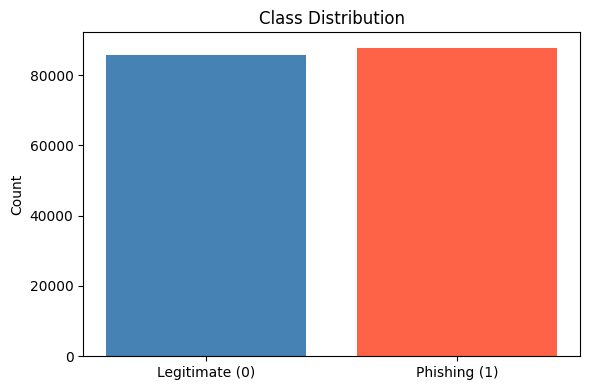

Class ratio: 1.02
Balance acceptable — no resampling needed.


In [ ]:
# ── Class Balance Check & Fix ─────────────────────────
counts = df['label'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Legitimate (0)', 'Phishing (1)'],
        [counts.get(0, 0), counts.get(1, 0)],
        color=['steelblue', 'tomato'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

ratio = counts.max() / counts.min()
print(f'Class ratio: {ratio:.2f}')

if ratio > 5:
    print('Imbalanced — applying undersampling...')
    minority_label = df['label'].value_counts().idxmin()
    majority_label = df['label'].value_counts().idxmax()
    minority = df[df.label == minority_label]
    majority = df[df.label == majority_label].sample(
        n=min(len(minority) * 3, len(df[df.label == majority_label])),
        random_state=SEED
    )
    df = pd.concat([minority, majority]).sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f'After balancing: {len(df):,} samples')
else:
    print('Balance acceptable — no resampling needed.')

## 6. Train / Validation / Test Split

In [ ]:

train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

print(f'Train : {len(train_df):,}')
print(f'Val   : {len(val_df):,}')
print(f'Test  : {len(test_df):,}')

Train : 138,736
Val   : 17,342
Test  : 17,342


## 7. Tokenizer & Dataset

In [ ]:
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')

Loading tokenizer: xlm-roberta-base


Tokenizer loaded.


In [ ]:
class PhishDataset(TorchDataset):
    """PyTorch Dataset for phishing text classification."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


train_dataset = PhishDataset(train_df['text'], train_df['label'], tokenizer, MAX_LEN)
val_dataset   = PhishDataset(val_df['text'],   val_df['label'],   tokenizer, MAX_LEN)
test_dataset  = PhishDataset(test_df['text'],  test_df['label'],  tokenizer, MAX_LEN)

print(f'Train dataset : {len(train_dataset):,} samples')
print(f'Val dataset   : {len(val_dataset):,} samples')
print(f'Test dataset  : {len(test_dataset):,} samples')

Train dataset : 138,736 samples
Val dataset   : 17,342 samples
Test dataset  : 17,342 samples


## 8. Load XLM-RoBERTa Model

In [ ]:
print(f'Loading model: {MODEL_NAME}')

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded. Parameters: {total_params:,}')

Loading model: xlm-roberta-base


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded. Parameters: 278,045,186


## 9. Metrics Function

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    acc = accuracy_score(labels, preds)
    return {
        'accuracy':  round(acc, 4),
        'f1':        round(f1, 4),
        'precision': round(precision, 4),
        'recall':    round(recall, 4)
    }

print('Metrics function defined.')

Metrics function defined.


## 10. Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_ratio=100,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_dir=os.path.join(OUTPUT_DIR, 'logs'),
    logging_steps=50,
    seed=SEED,
)

print('Training arguments set.')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments set.


## 11. Train Model

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('Starting training...')
trainer.train()
print('Training complete!')

Starting training...


Epoch,Training Loss,Validation Loss


## 12. Evaluate on Test Set

In [ ]:
print('Evaluating on test set...')
results = trainer.evaluate(test_dataset)

print('\n── Test Results ──────────────────────────')
print(f"Accuracy  : {results['eval_accuracy']:.4f}")
print(f"F1        : {results['eval_f1']:.4f}")
print(f"Precision : {results['eval_precision']:.4f}")
print(f"Recall    : {results['eval_recall']:.4f}")

In [ ]:
# ── Confusion Matrix ───────────────────────────────────
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Percentage
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (%)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(labels, preds, target_names=['Legitimate', 'Phishing']))

## 13. Save Model

In [ ]:
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f'Model saved to: {OUTPUT_DIR}')
print('Files saved:')
for f in os.listdir(OUTPUT_DIR):
    print(f'  {f}')

## 14. Build Predictor

In [ ]:
def predict_text(text, threshold=0.5):
    """
    Predict whether a text is phishing or legitimate.

    Args:
        text      : Input string (English or Bangla)
        threshold : Confidence threshold (default 0.5)

    Returns:
        dict with label, confidence, and probabilities
    """
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)[0].tolist()
    phishing_prob = probs[1]
    label = 'PHISHING' if phishing_prob >= threshold else 'LEGITIMATE'

    return {
        'label':      label,
        'confidence': round(max(probs), 4),
        'phishing_probability':   round(phishing_prob, 4),
        'legitimate_probability': round(probs[0], 4)
    }

print('predict_text() ready.')

## 15. Test Predictions

In [ ]:
test_cases = [
    # English phishing
    "URGENT: Your account has been suspended. Verify immediately at http://secure-login.xyz/verify",
    "Congratulations! You've won $1000. Click here to claim: bit.ly/win1000",
    "Your OTP is 482910. Do not share this with anyone.",

    # English legitimate
    "Hi, your order has been shipped and will arrive by Thursday.",
    "Meeting rescheduled to 3PM tomorrow. Please confirm.",

    # Bangla phishing
    "অভিনন্দন! আপনি ৯৯৯ টাকা বোনাস পেয়েছেন। এখনই নিন: bit.ly/4uvkKFOh",
    "আপনার অ্যাকাউন্ট বন্ধ হয়ে যাবে। এখনই যাচাই করুন: tinyurl.com/verify-bd",

    # Bangla legitimate
    "আপনার পার্সেলটি আগামীকাল পৌঁছে যাবে। ধন্যবাদ।"
]

print('=' * 60)
for text in test_cases:
    result = predict_text(text)
    icon = '🚨' if result['label'] == 'PHISHING' else '✅'
    print(f'{icon} [{result["label"]}] ({result["confidence"]*100:.1f}%)')
    print(f'   {text[:70]}...' if len(text) > 70 else f'   {text}')
    print()

## 16. Load Saved Model (For Future Use)

In [ ]:
# Run this cell in future sessions to reload without retraining

from transformers import AutoTokenizer, AutoModelForSequenceClassification

OUTPUT_DIR = r"E:\Project Demo\models\nlp_model"

tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)
model = AutoModelForSequenceClassification.from_pretrained(OUTPUT_DIR)

print('Model reloaded successfully.')

# Quick test
result = predict_text("Click here to verify your account: http://phish.xyz")
print(result)